Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

Load and Clean the Dataset

In [2]:
df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Recreate Testing/Validation Set

In [3]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Test set shape:", X_test.shape)

Test set shape: (1407, 19)


Load the Trained Logistic Regression and Random Forest Models

In [4]:
logistic_model = joblib.load(
    "../models/logistic_regression.joblib"
)

random_forest_model = joblib.load(
    "../models/random_forest.joblib"
)

Implement Evaluation Function

In [5]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

    return results

Run the Evaluation on Both Models

In [6]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

results = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Random Forest": random_forest_results
}).T

results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
Random Forest,0.789623,0.634483,0.491979,0.554217,0.813999


Classification Reports

In [7]:
print("Logistic Regression")
print(
    classification_report(
        y_test,
        logistic_model.predict(X_test)
    )
)

print("Random Forest")
print(
    classification_report(
        y_test,
        random_forest_model.predict(X_test)
    )
)

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Generate Confusion Matrix (Logistic Regression)

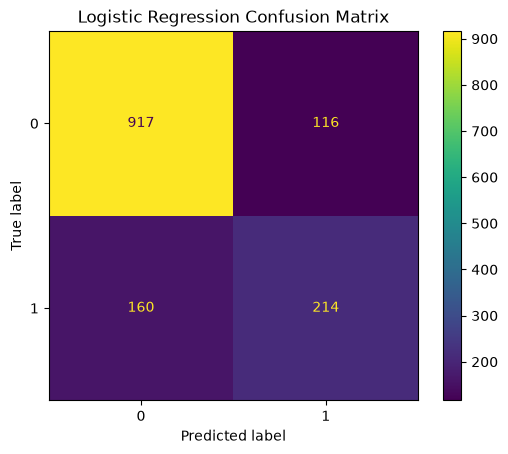

In [8]:
ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Generate Confusion Matrix (Random Forest)

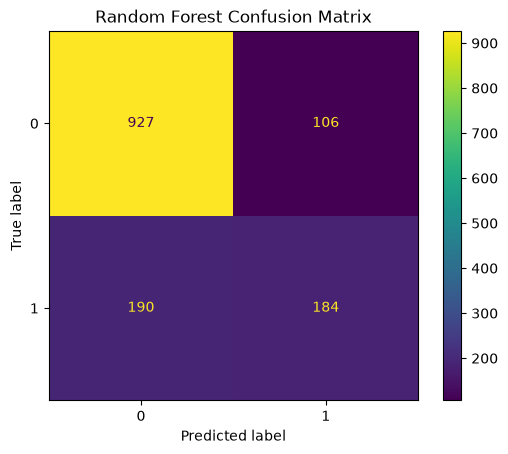

In [9]:
ConfusionMatrixDisplay.from_estimator(
    random_forest_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

Generate Receiver Operating Characteristic (ROC) Curves

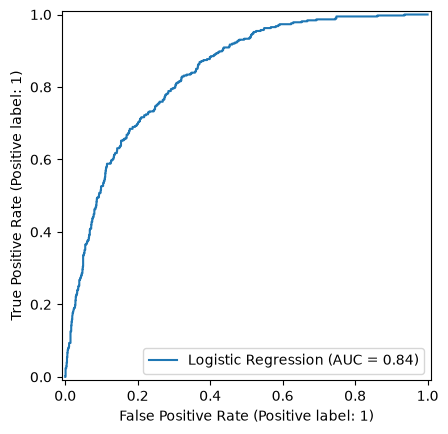

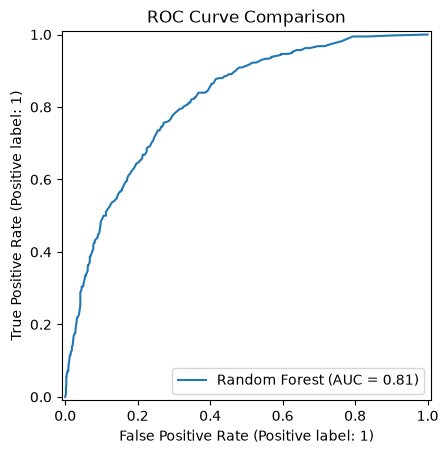

In [10]:
RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    random_forest_model,
    X_test,
    y_test,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

# Interpretation: The closer the curve is to the top-left corner, the better the model separates churners from non-churners.

Model Selection with F1-score

In [11]:
best_model_name = results["F1 Score"].idxmax()

print("Best model based on F1 Score:", best_model_name)

# Then select the corresponding model
if best_model_name == "Logistic Regression":
    best_model = logistic_model
else:
    best_model = random_forest_model

Best model based on F1 Score: Logistic Regression


Save the Selected Model

In [12]:
joblib.dump(
    best_model,
    "../models/churn_model.joblib"
)

print("Saved best model:", best_model_name)

"""
The saved pipeline includes:
Raw customer data
        ↓
Preprocessing
        ↓
Trained model
        ↓
Churn prediction
"""

Saved best model: Logistic Regression


'\nThe saved pipeline includes:\nRaw customer data\n        ↓\nPreprocessing\n        ↓\nTrained model\n        ↓\nChurn prediction\n'

Saved Model Verification

In [13]:
loaded_model = joblib.load(
    "../models/churn_model.joblib"
)

sample_predictions = loaded_model.predict(
    X_test.head(10)
)

print(sample_predictions)

# Note: If this prints an array of 0s and 1s, the saved pipeline works.

[0 1 0 0 0 0 0 0 1 0]
